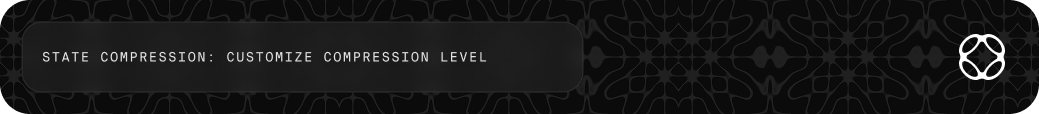

Use the `compression_level` parameter in `haiqu.state_compression()` to control the trade-off between circuit compression and state quality.

- For a 15-step Heisenberg evolution circuit, compression level can reduce the number of noisy two-qubit gates by as much as 71%.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.state_compression(): compression_level`

- **What does it do?** This parameter controls how much of the circuit is compressed, balancing circuit size reduction with state quality. Higher compression reduces more gates but may decrease the quality of the compressed state.
- **How do I use it?** Pass `compression_level` as a parameter to `haiqu.state_compression()` when creating a compression job, then retrieve results with `job.result()`.
- **What are the options?**
  - `low` – prioritizes quality over compression. Best for shallow circuits or low noise levels.
  - `balanced` (default) – best performance for most circuits and noise profiles.
  - `high` – compresses more of the circuit while maintaining acceptable quality. Best for very deep circuits.
- **Which option do you recommend?** Start with the default `balanced` setting for most use cases. Use `low` when state quality is critical and circuits are already shallow. Use `high` for very deep circuits where maximum compression is needed and some quality trade-off is acceptable.

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, and create an adder circuit to demonstrate state compression. The adder circuit adds two integers m and k.

In [1]:
import pandas as pd
import numpy as np
import qiskit

from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp

from haiqu.sdk import haiqu


def build_heisenberg_evolution_circuit(num_qubits, w, t, num_steps, seed=None):
    """
    Builds a quantum circuit of Trotterized Heisenberg evolution, started from the antiferromagnetic state.
    
    Parameters:
    - num_qubits (int): Number of qubits.
    - w (float): Intensity of the disorder
    - t (float): Time step
    - num_steps (int): Number of Trotter steps
    - seed (int|None): optional seed for setting the random field
    
    Returns:
    - QuantumCircuit implementing the Trotter evolution.
    """
    rng = np.random.default_rng(seed=seed)  # we specify the seed to be able to reproduce the circuits
    h_x = rng.uniform(-w, w, size=num_qubits)
    h_z = rng.uniform(-w, w, size=num_qubits)

    paulis = []  # pauli strings
    coeffs = []  # coefficients of the corresponding strings

    for i in range(num_qubits - 1):  # add ZZ, XX, YY components
        for op in ["Z", "X", "Y"]:
            pauli = ["I"] * num_qubits
            pauli[i] = op
            pauli[i + 1] = op
            
            paulis.append("".join(pauli))
            coeffs.append(1)

    # adding disorder components
    for i in range(num_qubits):
        pauli = ["I"] * num_qubits
        pauli[i] = "X"
        paulis.append("".join(pauli))
        coeffs.append(h_x[i])
    
        pauli = ["I"] * num_qubits
        pauli[i] = "Z"
        paulis.append("".join(pauli))
        coeffs.append(h_z[i])

    hamiltonian = SparsePauliOp(paulis, coeffs)  # creating the hamiltonian

    # creating an antiferromagnetic state
    qc_init = qiskit.QuantumCircuit(num_qubits)
    for i in range(0, num_qubits, 2):
        qc_init.x(i)

    # a circuit, implementing a single Trotter step
    trotter_step = PauliEvolutionGate(hamiltonian, time=t)

    # building the evolution circuit
    qc = qc_init.copy()
    for i in range(num_steps):
        qc = qc.compose(trotter_step)
    qc.name = "evolution"
    
    return qc

haiqu.login()
haiqu.init("State Compression Tutorial")

evolution_circuit = build_heisenberg_evolution_circuit(20, 1, 0.1, 15, seed=42)

evolution_circuit_meta = haiqu.transpile(evolution_circuit, device=haiqu.get_device("aer_simulator"))
evolution_circuit_meta.core_metrics()

CIRCUIT,evolution-on-aer_simulator
QUBITS,20
NUM PARAMETERS,0
DEPTH,157
2-Q GATES DEPTH,141
1-Q GATES,310
2-Q GATES,855
OTHER GATES,0
GATES TOTAL,1165
OTHER OPERATIONS,0
INSTRUCTIONS TOTAL,1165


## Run benchmark scenarios

Run experiments comparing original circuit, compressed circuit, and compressed circuit with mitigation on a noisy device:

In [2]:
# Initialize scenarios.
scenarios = [
    {"compression_level": "low", "description": "Low compression level"},
    {"compression_level": "balanced", "description": "Balanced (default) compression level"},
    {"compression_level": "high", "description": "High compression level"},
]
# Loop over scenarios and initialize results.
results = []
for scenario in scenarios:
    job_h = haiqu.state_compression(circuit=evolution_circuit, compression_level=scenario["compression_level"])
    circuit = job_h.result()

    cnot_compression = job_h.info["compression_percent"]
    
    # Store results for summary table.
    results.append({"cnot_compression": cnot_compression, "quality": job_h.quality, "description": scenario["description"]})

`compression_level` significantly changes the gates and depth reduction in the circuit. Summary of results:

In [3]:
def build_summary(results):
    """Build summary table data from experiment results."""
    return {
        'Configuration': [r["description"] for r in results],
        'CNOT compression': [r["cnot_compression"] for r in results],
        'Compression quality': [r["quality"] for r in results],
        'Business Impact': [
            'High quality of a compressed quantum state but low circuit reduction',
            'Medium quality of a state but much larger compression',
            'Very high circuit reduction but low quality of a quantum state',
        ]
    }

pd.set_option('display.max_colwidth', None)
pd.DataFrame(build_summary(results))

,Configuration,CNOT compression,Compression quality,Business Impact
0,Low compression level,24.152047,0.886967,High quality of a compressed quantum state but low circuit reduction
1,Balanced (default) compression level,51.754386,0.673041,Medium quality of a state but much larger compression
2,High compression level,68.947368,0.568733,Very high circuit reduction but low quality of a quantum state


> **🎲 Note:** Due to the stochastic nature of quantum sampling, these results will differ slightly between runs.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

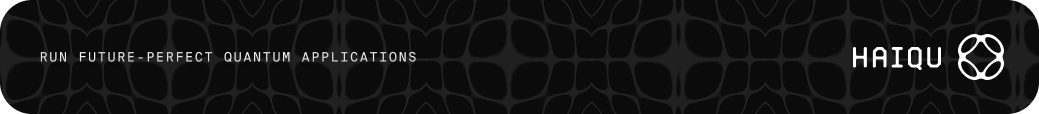